# Setup

In [ ]:
# Descomentar si se requiere usar google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
%%capture
!pip install PytorchWildlife
!pip install lightning

In [3]:
from PytorchWildlife.models import detection as pw_detection
from PytorchWildlife.models import classification as pw_classification
from PIL import Image, ImageDraw
from IPython.display import Image as IPImage
import matplotlib.pyplot as plt
import numpy as np
import os
import json

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Path to the training dataset
DATASET_PATH = os.path.join(
    "/content", "drive", "MyDrive", "ECHO", "snapshot_images"
)

In [49]:
# Load detector
DET_DEVICE = 'cuda'
DET_VERSION = 'MDV6-yolov10-e'
detector = pw_detection.MegaDetectorV6(
    device=DET_DEVICE,
    version=DET_VERSION
)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv10x summary (fused): 191 layers, 29,399,417 parameters, 0 gradients, 160.0 GFLOPs


# Utils

In [10]:
def load_json(path):
    with open(os.path.join(path), "r") as f:
        return json.load(f)

def save_json(data, filename):
    with open(os.path.join("json", filename), "w") as f:
        json.dump(data, f, indent=4)

In [77]:
DIR = 'tmp'
MIN_COUNT = 200
if not os.path.exists(DIR):
    os.mkdir(DIR)
total_species = 0
total_count = 0
classes = {}
for specie in os.listdir(DATASET_PATH):
  specie_path = os.path.join(DATASET_PATH, specie)
  if not os.path.isdir(specie_path):
    continue
  count_files = len(os.listdir(specie_path))
  if count_files < MIN_COUNT:
    continue
  if not classes.get(specie):
    classes[specie] = count_files
  total_species += 1
  total_count += count_files

id_to_specie = {}
specie_to_id = {}
for idx in range(0, len(classes)):
  id_to_specie[idx] = list(classes.keys())[idx]
  specie_to_id[list(classes.keys())[idx]] = idx

for cls, _ in sorted(classes.items(), key=lambda x: -x[1]):
  print(f"[{specie_to_id[cls]}] {cls}: {classes[cls]} ({round(classes[cls] / total_count, 2) * 100}%)")
print(f"Total species: {total_species}")

[0] Hued hued: 500 (8.0%)
[1] Pudu: 500 (8.0%)
[2] Puma: 500 (8.0%)
[4] Chucao: 500 (8.0%)
[5] Zorzal: 500 (8.0%)
[3] Guina: 314 (5.0%)
[8] Guanaco: 275 (4.0%)
[18] Zorro chilla: 255 (4.0%)
[19] Conejo europeo: 253 (4.0%)
[9] Huemul: 245 (4.0%)
[20] Gato domestico: 226 (4.0%)
[13] Vaca: 217 (4.0%)
[14] Zorro culpeo: 215 (3.0%)
[6] Caballo: 214 (3.0%)
[17] Jabali: 211 (3.0%)
[16] Quique: 207 (3.0%)
[12] Perro domestico: 206 (3.0%)
[11] Oveja: 204 (3.0%)
[10] Liebre europea: 203 (3.0%)
[15] Vison americano: 203 (3.0%)
[7] Chingue: 201 (3.0%)
Total species: 21


# Preprocessing

## Example

In [57]:
# Example detection and expected output
ex_img = "2019 12 31 06 16 44.jpg.png"
example_path = os.path.join(DATASET_PATH, id_to_specie[0], ex_img)
results = detector.single_image_detection(example_path)
detections = results["detections"].xyxy
confidences = results["detections"].confidence
image = Image.open(example_path)
draw = ImageDraw.Draw(image)

for bbox, conf in zip(detections, confidences):
  print(bbox, conf)
  x0,y0,x1,y1 = bbox
  draw.rectangle([(x0, y0), (x1, y1)], outline="red", width=8)

  draw.text((x0, y0-20), f"{conf:.2f}", fill="red")
  crop = image.crop((x0, y0, x1, y1))
  crop.save("/tmp/example_crop.jpg")
  image.save("/tmp/example_original.jpg")



0: 1280x1280 1 animal, 16377.7ms
Speed: 20.1ms preprocess, 16377.7ms inference, 0.4ms postprocess per image at shape (1, 3, 1280, 1280)
[     2003.4      1860.1      2206.9      2249.4] 0.9359314


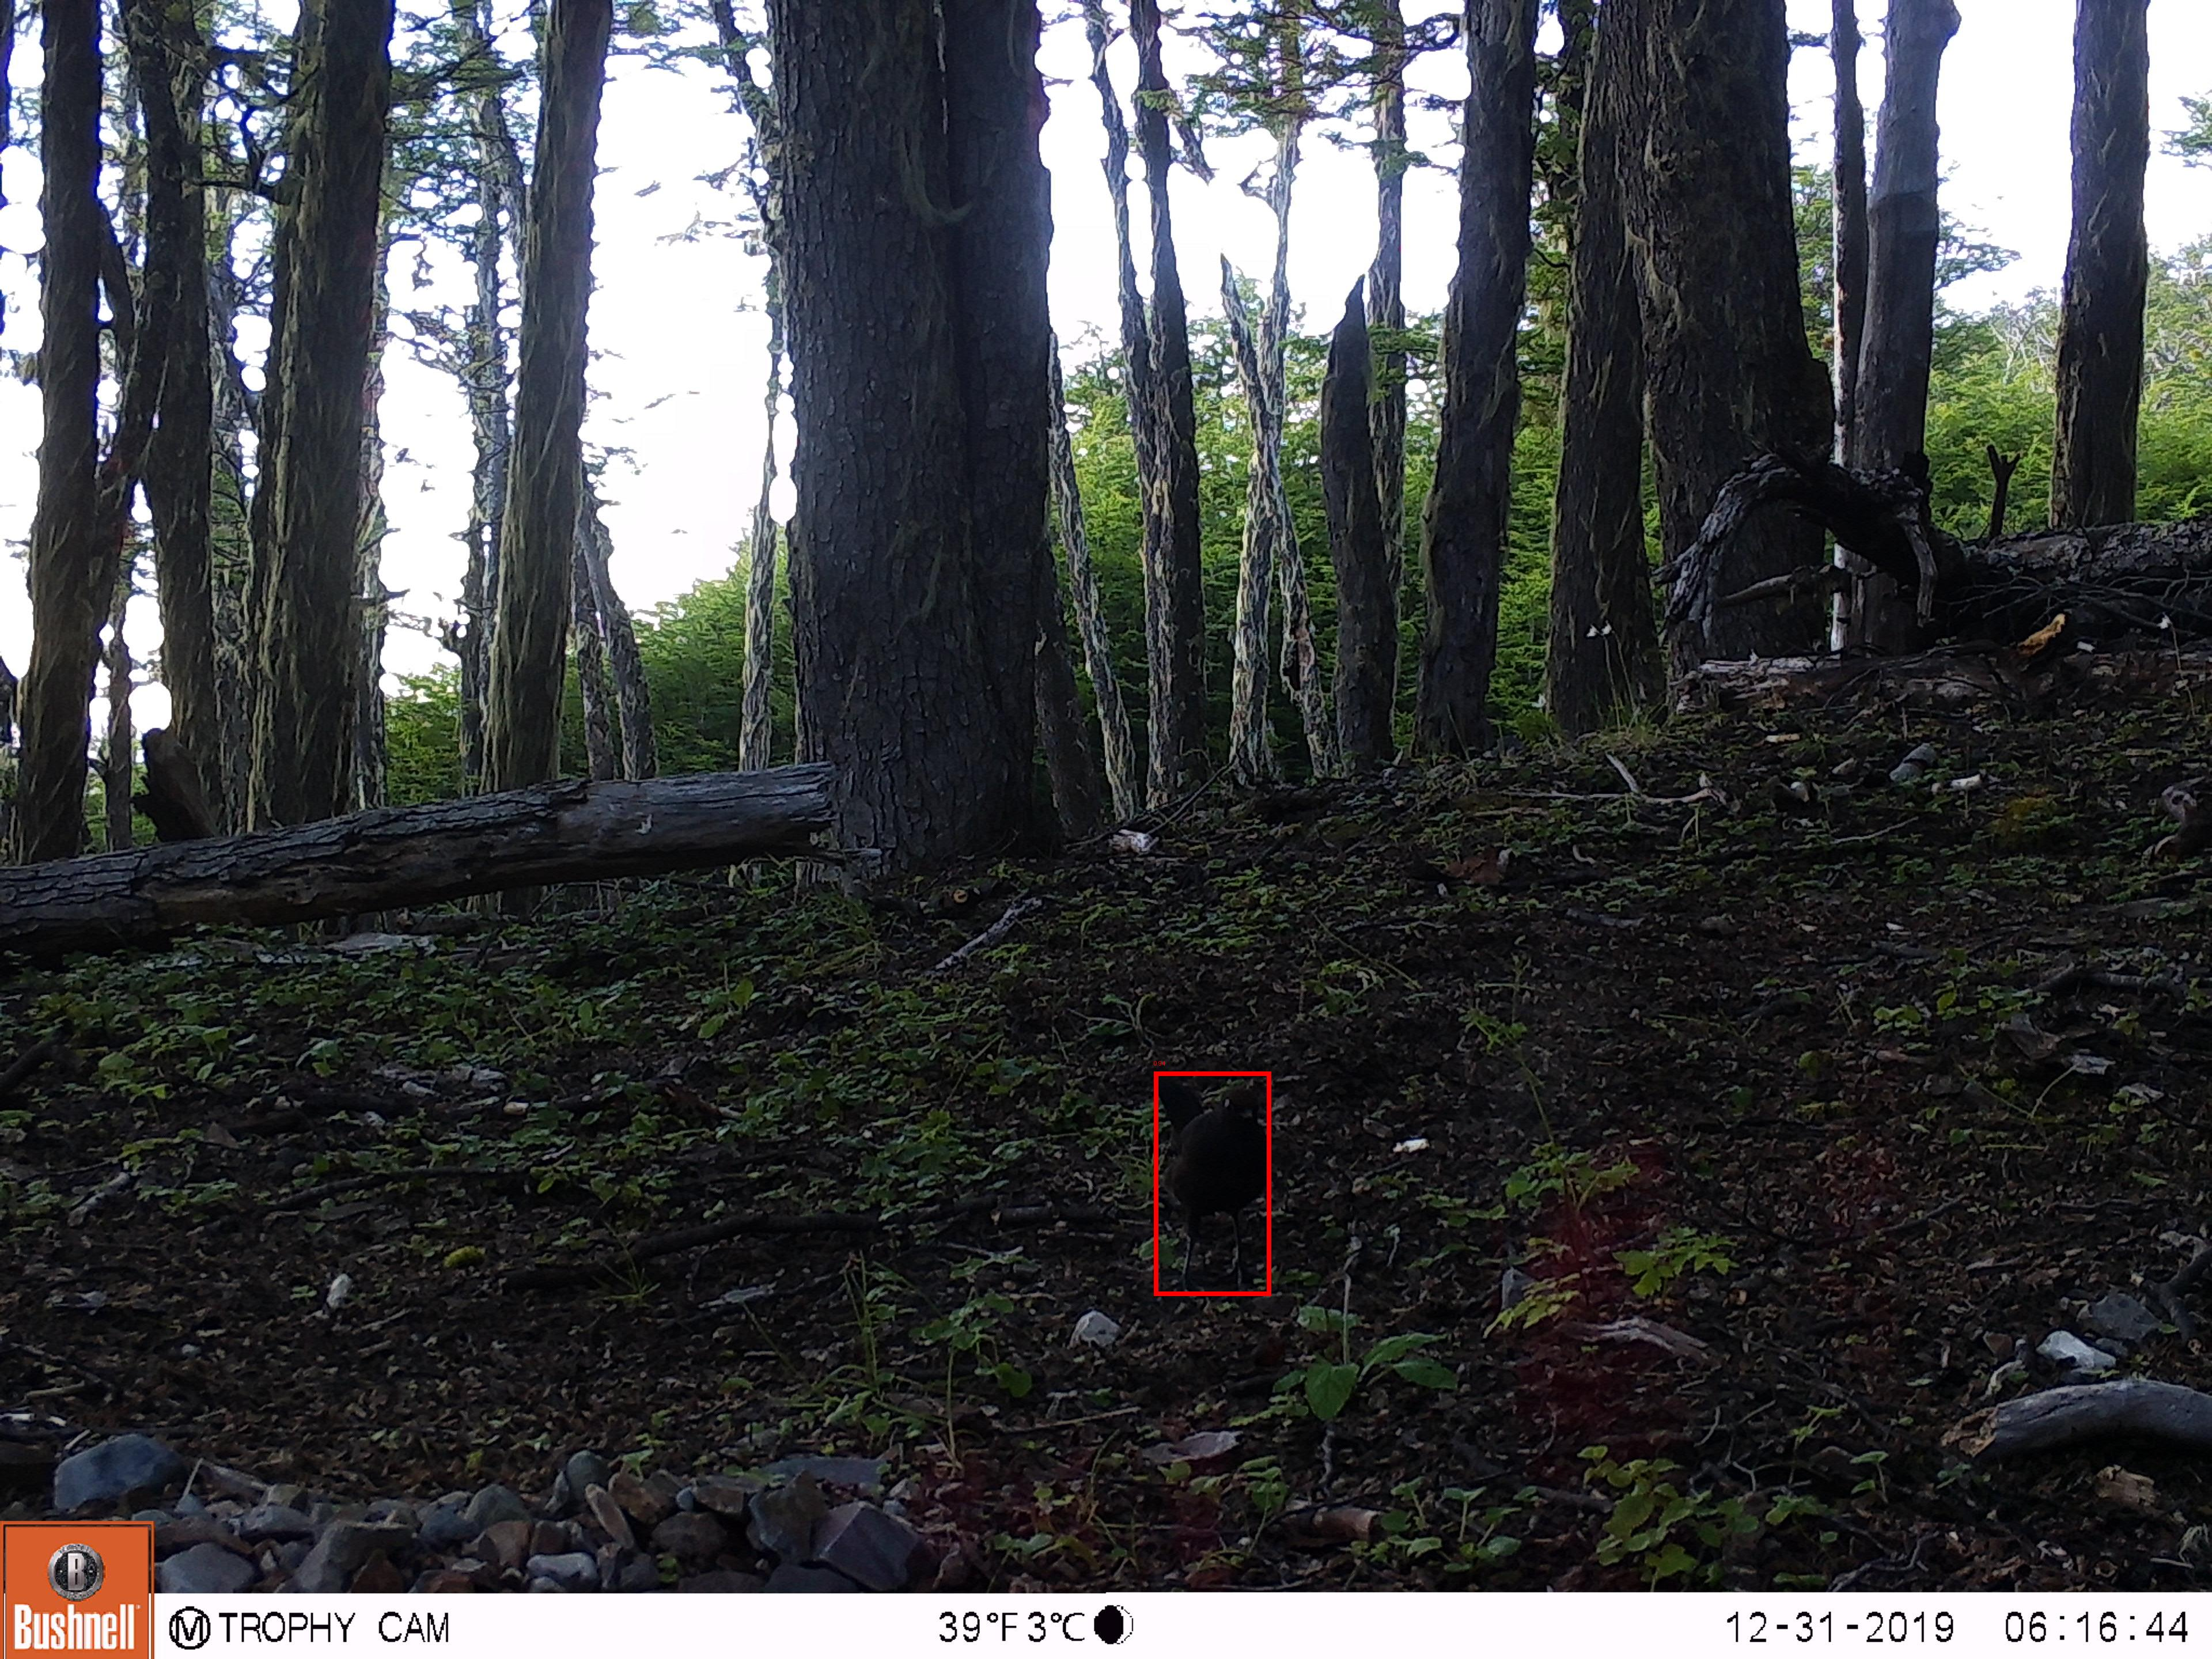

In [60]:
IPImage("/tmp/example_original.jpg")

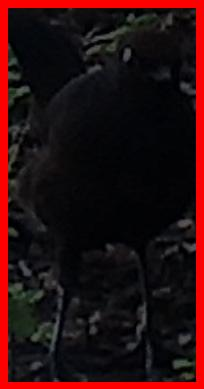

In [61]:
IPImage("/tmp/example_crop.jpg")

## Cropping

In [ ]:
DEST_PATH = os.path.join("/content", "tmp")
detections_metadata = {}

img_idx = 0
for cls in classes:
  # Creating directory for each class
  cls_idx = str(specie_to_id[cls])
  cls_path = os.path.join(DEST_PATH, cls_idx)
  if not os.path.exists(cls_path):
    os.mkdir(cls_path)

  # Get batch detections
  detections_metadata[cls_idx] = []
  source_path = os.path.join(DATASET_PATH, cls)

  print(f"Applying detector model in the image batches from /{cls}...")
  results = detector.batch_image_detection(source_path)

  # Saving the img bounding boxes and confidences
  for result in results:
    detections = result["detections"].xyxy
    confidences = result["detections"].confidence
    source_img_path = result["img_id"]
    dest_img_path = os.path.join(DEST_PATH, cls_idx, f"{img_idx}.jpg")
    detections_metadata[cls_idx].append({
        "source_img_path": source_img_path,
        "dest_img_path": dest_img_path,
        "detections": list(detections),
        "confidences": list(confidences),
    })
    img_idx += 1
  print(f"{img_idx} stored successfully at {cls_path} !")
  img_idx = 0 # Reset index for the next directory iteration
  break # DEBUG



Applying detector model in the image batches from /Hued hued...


  0%|          | 0/32 [00:00<?, ?it/s]